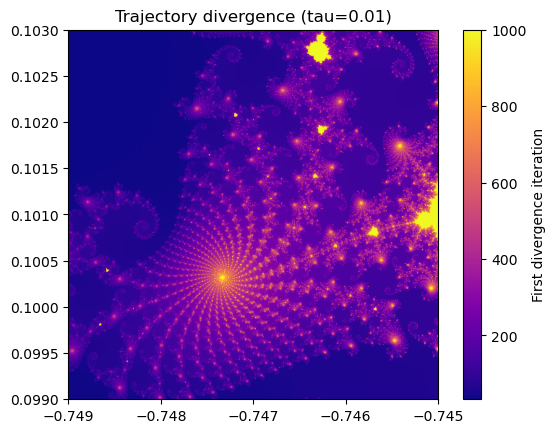

Fraction diverged early: 0.9923


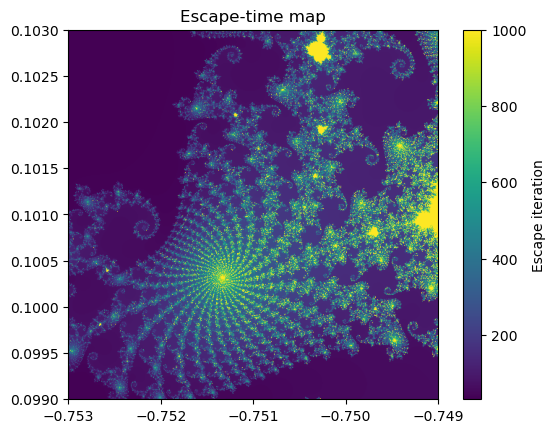

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N, MAX_ITER, TAU = 512, 1000, 0.01

x = np.linspace(-0.7490, -0.7450, N)
y = np.linspace(0.0990, 0.1030, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)

z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active = np.ones((N, N), dtype=bool)

"""
This snipet of code calculates the difference between the results of calculating the mandelbrot 
set in a small area with float 32 and 64 showcasing how they can create changes in precision
"""

for k in range(MAX_ITER):
    if not active.any():
        break

    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]

    diff = (
        np.abs(z32.real.astype(np.float64) - z64.real) +
        np.abs(z32.imag.astype(np.float64) - z64.imag)
    )

    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(
    diverge,
    cmap='plasma',
    origin='lower',
    extent=[-0.7490, -0.7450, 0.0990, 0.1030]
)

plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={TAU})')
plt.show()

fraction = np.mean(diverge < MAX_ITER)
print(f"Fraction diverged early: {fraction:.4f}")

z = np.zeros_like(C64)
escape = np.full((N, N), MAX_ITER, dtype=np.int32)

for k in range(MAX_ITER):
    mask = np.abs(z) <= 2
    z[mask] = z[mask]**2 + C64[mask]
    newly_escaped = mask & (np.abs(z) > 2)
    escape[newly_escaped] = k

plt.imshow(escape, cmap='viridis', origin='lower', extent=[-0.7530, -0.7490, 0.0990, 0.1030])
plt.colorbar(label='Escape iteration')
plt.title('Escape-time map')
plt.show()

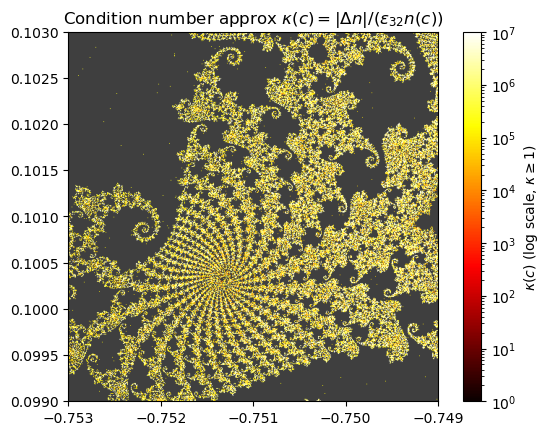

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER, TAU = 512, 1000, 0.01

x = np.linspace(-0.7490, -0.7450, N)
y = np.linspace(0.0990, 0.1030, N)

C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)

eps32 = np.finfo(np.float32).eps
delta = np.maximum(eps32 * np.abs(C), 1e-10)


def escape_count(C, max_iter):
    z = np.zeros_like(C)
    cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k
        esc[newly] = True

    return cnt


n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)

dn = np.abs(n_base - n_perturb)

kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)

cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')

vmax = np.nanpercentile(kappa, 99)

plt.imshow(
    kappa,
    cmap=cmap_k,
    origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030],
    norm=LogNorm(vmin=1, vmax=vmax)
)

plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n| / (\varepsilon_{32} n(c))$')

plt.show()